# STEP 1: BUSINESS UNDERSTANDING 
## 1.1 Problem Statement 

### We are building an Uber Ride Fare Prediction System that predicts the fare amount for a ride before it happens,
### using historical trip data such as pickup/drop locations, time, and trip distance.

## 1.2 Why This Problem Matters to Uber 


## I need to think like a business + data scientist.

### 1. Pricing Strategy Optimization
### a) Uber uses dynamic pricing (surge pricing)
### b) Accurate predictions help:
###    b.1) Set fair base prices
###    b.2) Avoid underpricing (loss) or overpricing (customer drop)

### Example:
### If my model predicts ₹250 but actual is ₹400 → revenue loss 

## 2. Customer Satisfaction
### a) Users hate:
### a.1) Price jumps
### a.2) Unexpected high fares

### With better prediction:

### Show accurate upfront pricing
### Increase trust & retention

## 3. Demand-Supply Matching
### a) Fare is linked to:
### a.1) Time (peak hours)
### a.2) Location (busy areas)

### b) Prediction helps:

### b.1) Identify high-demand zones
### b.2) Adjust driver availability

## 1.3 Type of Problem
### Machine Learning Type: Supervised Learning
### Task: Regression
### Target Variable: fare_amount

## 1.4 Key Inputs (Features)

### I will use:

### Pickup Latitude & Longitude
### Drop Latitude & Longitude
### Date & Time
### Passenger count

# STEP 2: DATA UNDERSTANDING + EDA

# 2.1 Load the Dataset

In [205]:
# import necessary library

import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("data/uber.csv")



# 2.2 Understand the Structure

In [206]:
df

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5
...,...,...,...,...,...,...,...,...,...
199995,42598914,2012-10-28 10:49:00.00000053,3.0,2012-10-28 10:49:00 UTC,-73.987042,40.739367,-73.986525,40.740297,1
199996,16382965,2014-03-14 01:09:00.0000008,7.5,2014-03-14 01:09:00 UTC,-73.984722,40.736837,-74.006672,40.739620,1
199997,27804658,2009-06-29 00:42:00.00000078,30.9,2009-06-29 00:42:00 UTC,-73.986017,40.756487,-73.858957,40.692588,2
199998,20259894,2015-05-20 14:56:25.0000004,14.5,2015-05-20 14:56:25 UTC,-73.997124,40.725452,-73.983215,40.695415,1


In [207]:
# Basic Inspection 
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [208]:
df.shape

(200000, 9)

In [209]:
df.columns

Index(['Unnamed: 0', 'key', 'fare_amount', 'pickup_datetime',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count'],
      dtype='object')

In [210]:
df.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


### What I Observe 
### 1) Number of rows & columns
### 2) Data types (object, float, int)
### 3) Missing values
### 4) Range of values

# 2.3 Data Quality Check 

In [211]:
# Duplicate Rows
df.duplicated().sum()

np.int64(0)

In [212]:
# Missing Values
df.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [213]:
# Invalid Values Check

df[df['fare_amount'] <= 0].count()

Unnamed: 0           22
key                  22
fare_amount          22
pickup_datetime      22
pickup_longitude     22
pickup_latitude      22
dropoff_longitude    22
dropoff_latitude     22
passenger_count      22
dtype: int64

In [214]:
df.shape

(200000, 9)

In [215]:
df[df['passenger_count'] <= 0]

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
333,2137942,2011-08-05 07:03:08.0000001,10.1,2011-08-05 07:03:08 UTC,-74.013900,40.707800,-73.992300,40.749300,0
908,8484351,2011-09-06 12:25:19.0000002,11.7,2011-09-06 12:25:19 UTC,-73.981000,40.764600,-73.962900,40.778400,0
926,32941306,2012-03-26 18:11:24.0000002,3.3,2012-03-26 18:11:24 UTC,-73.979978,40.765821,-73.983894,40.766873,0
2000,12591041,2012-04-20 15:07:57.0000003,15.7,2012-04-20 15:07:57 UTC,-73.975285,40.750138,-73.974729,40.783151,0
3011,39400625,2012-01-07 19:19:08.0000004,6.1,2012-01-07 19:19:08 UTC,-73.977900,40.789100,-73.983700,40.773600,0
...,...,...,...,...,...,...,...,...,...
196797,26965490,2011-01-17 15:52:26.0000002,3.3,2011-01-17 15:52:26 UTC,-74.000760,40.757637,-74.004852,40.751947,0
197103,49116579,2011-12-10 15:33:12.0000008,7.3,2011-12-10 15:33:12 UTC,0.000000,0.000000,0.000000,0.000000,0
198872,12988511,2011-09-20 19:55:05.0000001,5.7,2011-09-20 19:55:05 UTC,-73.980300,40.742800,-73.967900,40.755600,0
198902,54393172,2011-08-22 21:10:56.0000002,12.1,2011-08-22 21:10:56 UTC,-73.996700,40.737200,-74.008500,40.704000,0


### Fare cannot be ≤ 0
### Passenger count cannot be 0

## 2.4 Convert Datetime
### We will extract hour, day, month later .


In [216]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

## 2.6 Outlier Detection (VERY IMPORTANT)

### Fare Distribution

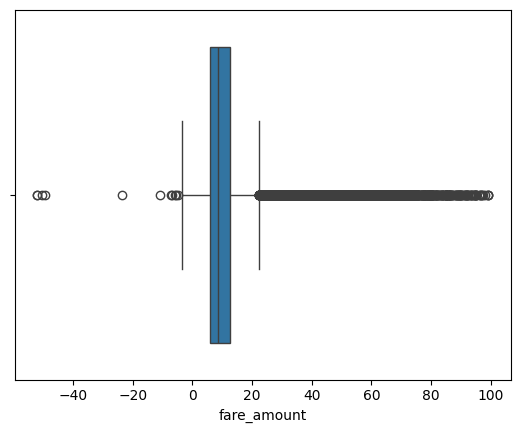

In [217]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(x=df[df['fare_amount'] < 100]['fare_amount'])

plt.show()

### Passenger Count

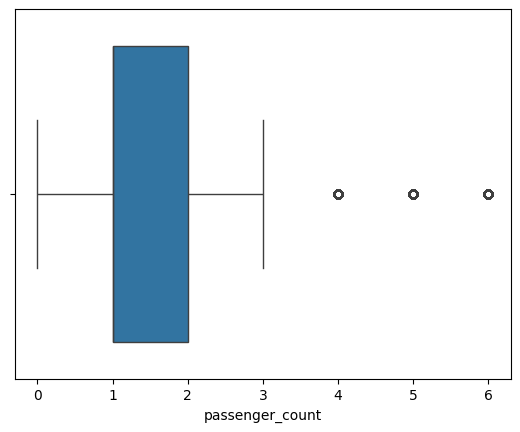

In [218]:
sns.boxplot(
    x=df[df['passenger_count'] <= 10]['passenger_count']
)

plt.show()

## What I Will Notice
### 1) Extremely high fares (₹5000+)
### 2) Unrealistic passenger counts (>6)

### These are data errors or rare cases

## 2.7 Geographical Sanity Check
### Coordinates must lie within valid Earth ranges

In [219]:
df[(df['pickup_latitude'] > 90) | (df['pickup_latitude'] < -90)]

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
56617,14257861,2012-03-11 07:24:00.00000031,8.1,2012-03-11 07:24:00+00:00,-73.960828,404.433332,-73.988357,40.769037,1
61793,2849369,2012-06-13 05:45:00.0000006,8.5,2012-06-13 05:45:00+00:00,-73.951385,401.066667,-73.982110,40.754117,1
75851,33249845,2011-11-05 00:22:00.00000051,15.7,2011-11-05 00:22:00+00:00,-1340.648410,1644.421482,-3356.666300,872.697628,1
91422,23566642,2011-05-18 13:24:00.000000213,16.1,2011-05-18 13:24:00+00:00,57.418457,1292.016128,1153.572603,-881.985513,1


In [220]:
df[(df['pickup_longitude'] > 180) | (df['pickup_longitude'] < -180)]

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
4949,42931506,2012-04-28 00:58:00.000000235,4.9,2012-04-28 00:58:00+00:00,-748.016667,40.739957,-74.003570,40.734192,1
48506,1055960,2011-11-05 23:26:00.000000309,33.7,2011-11-05 23:26:00+00:00,-735.200000,40.770092,-73.980187,40.765530,1
75851,33249845,2011-11-05 00:22:00.00000051,15.7,2011-11-05 00:22:00+00:00,-1340.648410,1644.421482,-3356.666300,872.697628,1
103745,16826862,2011-10-14 19:04:00.000000202,12.9,2011-10-14 19:04:00+00:00,-736.216667,40.767035,-73.982377,40.725562,1
144253,9421322,2009-08-26 11:55:00.00000023,7.3,2009-08-26 11:55:00+00:00,-768.550000,40.757812,-73.997040,40.740007,1
161652,25264921,2010-05-12 12:19:00.00000098,4.1,2010-05-12 12:19:00+00:00,-735.433332,40.740605,-74.006373,40.739607,1
199936,44787414,2012-07-21 16:19:00.00000099,4.1,2012-07-21 16:19:00+00:00,-736.400000,40.774307,-73.982215,40.769672,5


## 2.8 Business Insights 

### I Don’t just plot — interpret for the insights

## Insight 1: Fare Distribution

### 1) Most rides are low to medium fare
### 2) Few high fares → long-distance or surge ride  


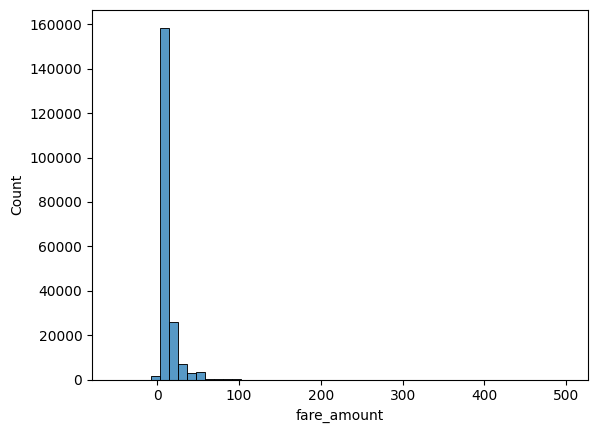

In [221]:
sns.histplot(df['fare_amount'], bins=50)
plt.show()

## Insight 2: Passenger Count

### 1) Most rides have 1–2 passengers
### 2) Helps in ride optimization

In [222]:
df['passenger_count'].value_counts()

passenger_count
1      138425
2       29428
5       14009
3        8881
4        4276
6        4271
0         709
208         1
Name: count, dtype: int64

## Insight 3: Time Patterns

### a) Peak hours → morning & evening
### b) Important for surge pricing 


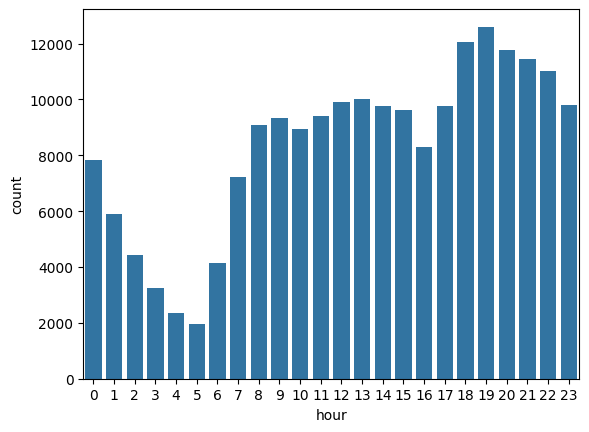

In [223]:
df['hour'] = df['pickup_datetime'].dt.hour
sns.countplot(x=df['hour'])
plt.show()

## 2.9 Initial Cleaning 

In [224]:
# Remove invalid fares
df = df[df['fare_amount'] > 0]

In [225]:
# Remove invalid passengers
df = df[(df['passenger_count'] > 0) & (df['passenger_count'] <= 6)]

In [226]:
# Drop missing values
df = df.dropna()

In [227]:
df.shape

(199268, 10)

In [228]:
df.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
hour                 0
dtype: int64

In [229]:
df.duplicated().sum()

np.int64(0)

In [230]:
df['Unnamed: 0'].head()

0    24238194
1    27835199
2    44984355
3    25894730
4    17610152
Name: Unnamed: 0, dtype: int64

In [231]:
df = df.drop(columns=['Unnamed: 0'])

# The column appeared to be an index artifact from data storage.
# It had no business meaning and no predictive power.
# Including it could introduce noise and lead to overfitting,
# so I removed it to improve model generalization.

In [232]:
df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour
0,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,19
1,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,20
2,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,21
3,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,8
4,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,17


In [233]:
df = df.drop(columns=['key'])

# The column appeared to be a unique identifier rather than a feature with predictive power. 
# Since it has no relationship with the target variable and could introduce noise or lead
# to overfitting,I removed it.

In [234]:
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,19
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,20
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,21
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,8
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,17


# STEP 3: FEATURE ENGINEERING + DATA CLEANING

## Data Cleaning (Advanced Level)

## 1. Remove Invalid Coordinates
### Invalid GPS → wrong distance → wrong fare prediction 

In [235]:
df = df[
    (df['pickup_latitude'].between(-90, 90)) &
    (df['pickup_longitude'].between(-180, 180)) &
    (df['dropoff_latitude'].between(-90, 90)) &
    (df['dropoff_longitude'].between(-180, 180))
]

In [236]:
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,19
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,20
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,21
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,8
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,17


In [237]:
df.shape


(199256, 8)

## 2. Remove Extreme Outliers (Statistical Method)

## Using IQR (Industry Standard)
### a) Removes unrealistic fares
### b) Prevents model distortion


In [238]:
Q1 = df['fare_amount'].quantile(0.25)
Q3 = df['fare_amount'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['fare_amount'] >= Q1 - 1.5 * IQR) & 
        (df['fare_amount'] <= Q3 + 1.5 * IQR)]

## 3. Feature Engineering

## 3.1 Distance Calculation (MOST IMPORTANT FEATURE)

### Using the Haversine Formula

In [239]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    
    lat1, lon1, lat2, lon2 = map(np.radians, 
                                 [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

df['distance_km'] = haversine(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

### Note: a) Without distance:
###       Model is blind

###       b) With distance:
###       Model understands fare logic

## 3.2 Time-Based Features

In [240]:
df['hour'] = df['pickup_datetime'].dt.hour
df['day'] = df['pickup_datetime'].dt.day
df['month'] = df['pickup_datetime'].dt.month
df['weekday'] = df['pickup_datetime'].dt.weekday

# Feature -->	Business Meaning
# hour -->	    Peak vs non-peak
# weekday -->	Weekday vs weekend
# month	   --> Seasonal trends

# 3.3 Peak Hour Feature 
## Captures surge pricing behavior

In [241]:
df['is_peak_hour'] = df['hour'].apply(lambda x: 1 if (7 <= x <= 10 or 16 <= x <= 20) else 0)

# 3.4 Remove Unrealistic Distances

## 0 km → wrong data

## 100 km → unlikely  a Uber ride 

In [242]:
df = df[df['distance_km'] > 0]
df = df[df['distance_km'] < 100]

# 4. Separate Input & Output

In [243]:
X = df.drop(columns=['fare_amount', 'pickup_datetime'])
y = df['fare_amount']

In [244]:
X

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,distance_km,day,month,weekday,is_peak_hour
0,-73.999817,40.738354,-73.999512,40.723217,1,19,1.683323,7,5,3,1
1,-73.994355,40.728225,-73.994710,40.750325,1,20,2.457590,17,7,4,1
2,-74.005043,40.740770,-73.962565,40.772647,1,21,5.036377,24,8,0,0
3,-73.976124,40.790844,-73.965316,40.803349,3,8,1.661683,26,6,4,1
4,-73.925023,40.744085,-73.973082,40.761247,5,17,4.475450,28,8,3,1
...,...,...,...,...,...,...,...,...,...,...,...
199994,-73.983070,40.760770,-73.972972,40.754177,1,14,1.122878,31,1,4,0
199995,-73.987042,40.739367,-73.986525,40.740297,1,10,0.112210,28,10,6,1
199996,-73.984722,40.736837,-74.006672,40.739620,1,1,1.875050,14,3,4,0
199998,-73.997124,40.725452,-73.983215,40.695415,1,14,3.539715,20,5,2,0


In [245]:
y

0          7.5
1          7.7
2         12.9
3          5.3
4         16.0
          ... 
199994    12.0
199995     3.0
199996     7.5
199998    14.5
199999    14.1
Name: fare_amount, Length: 176651, dtype: float64

# Insight: 
# a) fare_amount is target
# b) pickup_datetime already converted → no need to keep raw

# STEP 4: SCALING + TRAIN-TEST SPLIT

In [246]:
X.columns

Index(['pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count', 'hour', 'distance_km', 'day',
       'month', 'weekday', 'is_peak_hour'],
      dtype='object')

In [247]:
# 4.1 Train-Test Split 

# We need split data because
# To evaluate model performance on unseen data and avoid overfitting.

# 80% → Training
# 20% → Testing
# random_state=42 → reproducibility

In [248]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [249]:
# 4.2 Scaling (Standardization)
# We will use StandardScaler

# Scaling ensures that all features contribute equally to the model and prevents
# features with larger magnitudes from dominating the learning process.

In [250]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

# Compute Correlation Matrix

In [251]:
corr_matrix = df.corr(numeric_only=True)

corr_matrix

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,distance_km,day,month,weekday,is_peak_hour
fare_amount,1.000000,0.001204,-0.002014,0.002047,-0.002214,0.013017,-0.013121,0.723498,0.006575,0.026705,0.020356,-0.030133
pickup_longitude,0.001204,1.000000,-0.993709,0.999963,-0.993716,0.009836,0.002746,-0.008440,0.018511,-0.007082,0.006676,-0.000804
pickup_latitude,-0.002014,-0.993709,1.000000,-0.993727,0.999953,-0.010161,-0.002101,0.008686,-0.019015,0.007518,-0.007260,0.001945
dropoff_longitude,0.002047,0.999963,-0.993727,1.000000,-0.993691,0.009861,0.002455,-0.007633,0.018477,-0.007092,0.006766,-0.001386
dropoff_latitude,-0.002214,-0.993716,0.999953,-0.993691,1.000000,-0.010129,-0.002171,0.008949,-0.019038,0.007504,-0.007185,0.001753
passenger_count,0.013017,0.009836,-0.010161,0.009861,-0.010129,1.000000,0.015268,0.000195,0.002853,0.008511,0.037659,-0.018356
hour,-0.013121,0.002746,-0.002101,0.002455,-0.002171,0.015268,1.000000,-0.032688,0.005660,-0.003065,-0.088033,0.128276
distance_km,0.723498,-0.008440,0.008686,-0.007633,0.008949,0.000195,-0.032688,1.000000,0.006123,0.005301,0.034328,-0.053593
day,0.006575,0.018511,-0.019015,0.018477,-0.019038,0.002853,0.005660,0.006123,1.000000,-0.016307,0.004745,-0.000964
month,0.026705,-0.007082,0.007518,-0.007092,0.007504,0.008511,-0.003065,0.005301,-0.016307,1.000000,-0.009565,-0.007206


# Visualize (Heatmap)

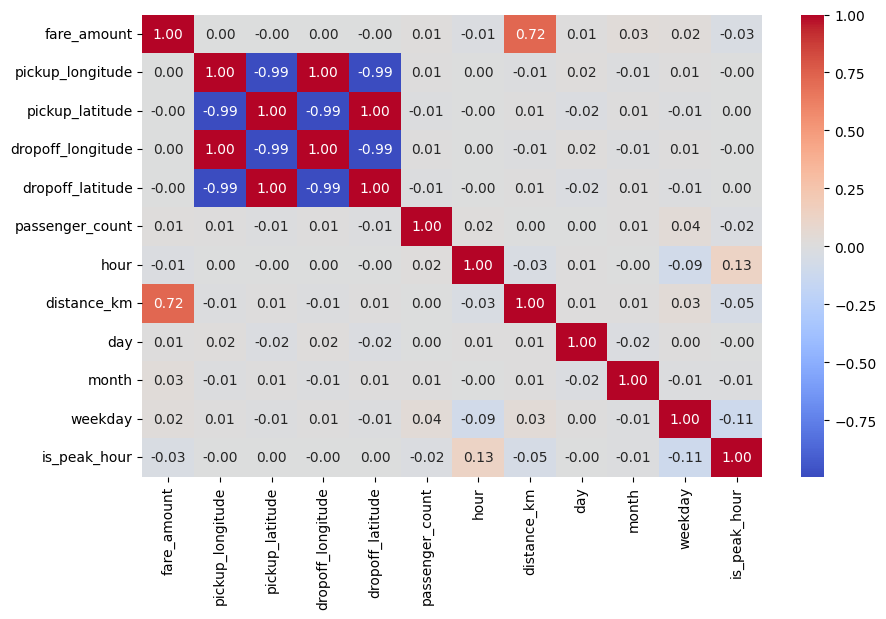

In [252]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [253]:
# Correlation with Target (fare_amount)

In [254]:
corr_matrix['fare_amount'].sort_values(ascending=False)

fare_amount          1.000000
distance_km          0.723498
month                0.026705
weekday              0.020356
passenger_count      0.013017
day                  0.006575
dropoff_longitude    0.002047
pickup_longitude     0.001204
pickup_latitude     -0.002014
dropoff_latitude    -0.002214
hour                -0.013121
is_peak_hour        -0.030133
Name: fare_amount, dtype: float64

### Distance has the strongest correlation with fare,
### confirming it as the primary driver. Time-based features show moderate influence, 
### likely due to surge pricing patterns. Passenger count has minimal impact, 
### indicating pricing is largely independent of occupancy.

# STEP 5: MODEL BUILDING 

## We will build:

### 1) Linear Regression
### 2) Decision Tree Regressor
### 3) Random Forest Regressor
### 4) XGBoost Regressor

### Then compare:

### 1) RMSE
### 2) MAE
### 3) R² Score

# 5.1 Import Models & Metrics

In [255]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# 5.2 Create Evaluation Function 

## Instead of repeating code again and again, we create a reusable function.

In [256]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    r2 = r2_score(y_test, y_pred)
    
    print(f"Model: {model.__class__.__name__}")
    print("-" * 40)
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")
    
    return {
        "Model": model.__class__.__name__,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

### I created a reusable evaluation pipeline to maintain clean, scalable, and modular code.

# 5.3 Linear Regression

## 1) Linear Regression assumes:

## y=mx+b

## 2)  It tries to find the best linear relationship between features and fare.

In [257]:
lr_model = LinearRegression()

lr_results = evaluate_model(
    lr_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

Model: LinearRegression
----------------------------------------
MAE  : 1.88
RMSE : 2.65
R²   : 0.5894


# Strengths of Linear Model: 
## 1) Simple
## 2) Fast|
## 3) Highly interpretable

# Weaknesses of Linear Regression
### 1) Cannot capture complex relationships
### 2) Sensitive to outliers

# 5.4 Decision Tree Regressor

# What it does ?
## 1) Splits data into decision rules
## 2) Learns non-linear patterns

In [258]:
dt_model = DecisionTreeRegressor(
    max_depth=8,
    random_state=42
)

dt_results = evaluate_model(
    dt_model,
    X_train,
    X_test,
    y_train,
    y_test
)

Model: DecisionTreeRegressor
----------------------------------------
MAE  : 1.58
RMSE : 2.23
R²   : 0.7090


# Strengths of Decision Tree Regressor:
## 1) Captures non-linear relationships
## 2) Easy to visualize

# Weaknesses of Decision Tree Regressor:
## 1) Overfitting risk
## 2) Unstable

# 5.5 Random Forest Regressor

# What it does:
## 1) Combines multiple decision trees
## 2) Uses ensemble learning

## 3) Final prediction = average of many trees

In [259]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_results = evaluate_model(
    rf_model,
    X_train,
    X_test,
    y_train,
    y_test
)

Model: RandomForestRegressor
----------------------------------------
MAE  : 1.53
RMSE : 2.16
R²   : 0.7258


# Strengths of Random Forest Regressor:
## 1) Very powerful
## 2) Handles non-linearity
## 3) Reduces overfitting

# Weakness of Random Forest Regressor
## 1) Slower
## 2) Less interpretable

# 5.6 XGBoost Regressor

# What it does:

## XGBoost uses:
 
## 1) Gradient boosting
## 2) Sequential learning

## Each tree:

## Corrects previous tree errors

In [260]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_results = evaluate_model(
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

Model: XGBRegressor
----------------------------------------
MAE  : 1.45
RMSE : 2.07
R²   : 0.7480


# 5.7 Compare All Models

In [261]:
results_df = pd.DataFrame([
    lr_results,
    dt_results,
    rf_results,
    xgb_results
])

results_df.sort_values(by='RMSE')

,Model,MAE,RMSE,R2
3,XGBRegressor,1.453819,2.072300,0.748036
2,RandomForestRegressor,1.533045,2.161922,0.725771
1,DecisionTreeRegressor,1.583008,2.226867,0.709048
0,LinearRegression,1.883727,2.645506,0.589370


---
# MAE (Mean Absolute Error)

# Average prediction error.

# Lower = better
---


# RMSE (Root Mean Square Error)

# Punishes large errors heavily.

# Lower = better
---

# R² Score

# Measures explained variance.

# Closer to 1 → better
---

# We choose:

# Best performance
# Stable generalization
# Reasonable training time
---

In [262]:
# Training score
print("RF Train Score:", rf_model.score(X_train, y_train))
print("RF Test Score :", rf_model.score(X_test, y_test))

print("XGB Train Score:", xgb_model.score(X_train, y_train))
print("XGB Test Score :", xgb_model.score(X_test, y_test))

RF Train Score: 0.7547946997810735
RF Test Score : 0.7257713563911736
XGB Train Score: 0.767405028933798
XGB Test Score : 0.7480364102143753


# STEP 6: CROSS-VALIDATION + HYPERPARAMETER TUNING

---
# This is where we:

## 1) Validate model stability
## 2) Prevent overfitting
## 3) Optimize performance scientifically
---

# PART 1 — CROSS VALIDATION
---

# 6.1 Why Cross-Validation?
---

## Cross-validation ensures:

### Model performs consistently across different data splits.
---

## Instead of evaluating once:

### We train/evaluate multiple times on different folds.
---

# 6.2 K-Fold Cross Validation
---

# Most common:

## 1) 5-Fold CV

# Meaning:

## 1) Dataset split into 5 parts
## 2) Train on 4
## 3) Test on 1
## 4) Repeat 5 times
---

# Visual Idea
### Fold 1 → Test
### Fold 2 → Test
### Fold 3 → Test
### Fold 4 → Test
### Fold 5 → Test

### Final score = average performance
---

# 6.3 Apply Cross Validation

In [263]:
# We usually apply it to:

# Random Forest
# XGBoost

# because they are strongest models.

In [264]:
from sklearn.model_selection import cross_val_score

rf_cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

rf_rmse_scores = -rf_cv_scores

print("Random Forest CV RMSE Scores:")
print(rf_rmse_scores)

print("\nAverage RMSE:")
print(rf_rmse_scores.mean())

Random Forest CV RMSE Scores:
[2.14983844 2.1245726  2.1722696  2.19084066 2.14444456]

Average RMSE:
2.156393171730901


In [265]:
# Interpretation

# Example:

# [2.31, 2.28, 2.35, 2.29, 2.33]

#  Meaning:

# Model is stable
# Low variance

In [266]:
# Overfitting Detection

# If scores vary wildly:

# [2.1, 5.9, 1.8, 6.2, 2.0]

---
# 6.4 XGBoost Cross Validation

In [267]:
xgb_cv_scores = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

xgb_rmse_scores = -xgb_cv_scores

print("XGBoost CV RMSE Scores:")
print(xgb_rmse_scores)

print("\nAverage RMSE:")
print(xgb_rmse_scores.mean())

XGBoost CV RMSE Scores:
[2.06870379 2.03543522 2.10040723 2.11385165 2.06034728]

Average RMSE:
2.0757490335902538


# PART 2 — HYPERPARAMETER TUNING

## 6.5 What are Hyperparameters?


### These are settings that control model learning.

### Example:

### 1) Number of trees
### 2) Tree depth
### 3) Learning rate

In [268]:
# Why Tuning Matters

# Bad parameters:

# Overfitting
# Underfitting
# Slow training

# Good parameters:

# Better generalization
# Higher accuracy

# 6.6 GridSearchCV (Industry Standard)

## Step 1: Define Parameter Grid

In [269]:
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [270]:
# Meaning of Parameters
# Parameter -->	Meaning
# n_estimator	--> Number of trees
# max_depth --> 	Tree depth
# min_samples_split -->	Min samples to split
# min_samples_leaf --> 	Minimum leaf size

# 6.7 Run GridSearchCV

In [271]:
from sklearn.model_selection import GridSearchCV

grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid_rf,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold 

# Extract Best Parameters

In [272]:
print("Best Parameters:")
print(grid_rf.best_params_)

print("\nBest RMSE:")
print(-grid_rf.best_score_)

Best Parameters:
{'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

Best RMSE:
2.1109807852458995


# 6.8 Train Final Optimized Model

In [273]:
best_rf_model = grid_rf.best_estimator_

In [274]:
print(best_rf_model)

RandomForestRegressor(max_depth=15, min_samples_leaf=2, min_samples_split=5,
                      random_state=42)


# 6.9 Evaluate Optimized Model

In [275]:
best_rf_results = evaluate_model(
    best_rf_model,
    X_train,
    X_test,
    y_train,
    y_test
)

Model: RandomForestRegressor
----------------------------------------
MAE  : 1.48
RMSE : 2.10
R²   : 0.7400


In [276]:
# Hyperparameter tuning can improve performance dramatically
# But excessive tuning may:
# increase complexity
# training cost

# So balance matters.

# STEP 7: FEATURE IMPORTANCE + ERROR ANALYSIS + MODEL INTERPRETATION

## 7.1 FEATURE IMPORTANCE ANALYSIS

In [277]:
# We want to know:

# Which features influence fare prediction the most?

# This is critical for:

# Business decisions
# Trust in model
# Explainability


In [278]:
# Extract Feature Importance

In [279]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
6,distance_km,0.842660
3,dropoff_latitude,0.030798
2,dropoff_longitude,0.027324
0,pickup_longitude,0.023677
1,pickup_latitude,0.021318
5,hour,0.020697
7,day,0.010439
9,weekday,0.009316
8,month,0.009007
4,passenger_count,0.003420


## 7.2 Visualize Feature Importance

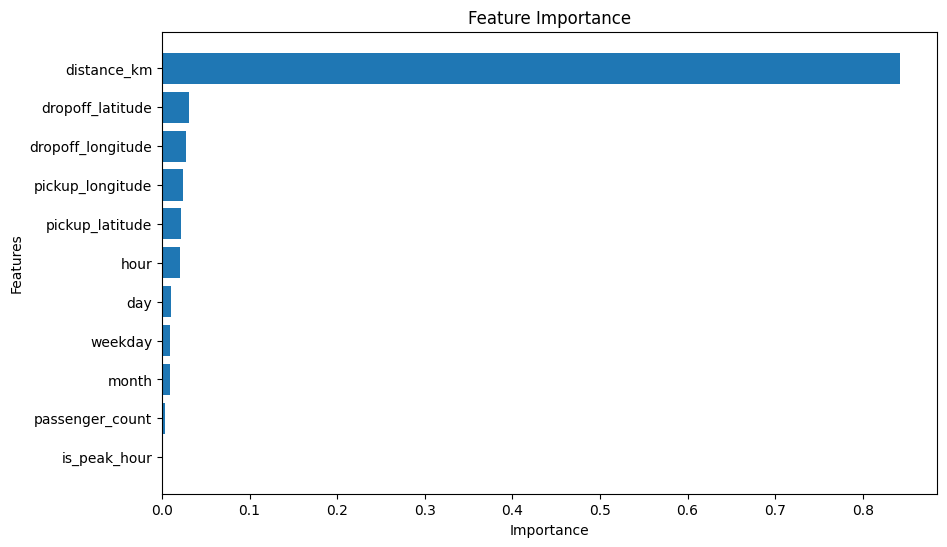

In [280]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [281]:
# Expected Result

In [282]:
# Feature	Importance
# distance_km	Highest 
# hour	Moderate
# is_peak_hour	Moderate
# passenger_count	Low

# BUSINESS INTERPRETATION

## Insight 1: Distance Dominates Pricing

In [283]:
# If distance_km highest:

# “Trip distance is the strongest driver of fare pricing, 
# which aligns with Uber’s pricing strategy where fare increases proportionally with ride distance.”


## Insight 2: Peak Hours Affect Pricing

In [284]:
# If hour or is_peak_hour important:

# “Temporal features indicate that fare pricing is influenced by demand 
#  patterns and surge pricing during peak traffic hours.”



## Insight 3: Passenger Count Low Impact

In [285]:
# “Passenger count has minimal influence, suggesting that standard ride pricing is 
# mostly independent of occupancy.”

# 7.3 PREDICTION vs ACTUAL ANALYSIS

In [286]:
# Generate Predictions

In [287]:
y_pred = best_rf_model.predict(X_test)

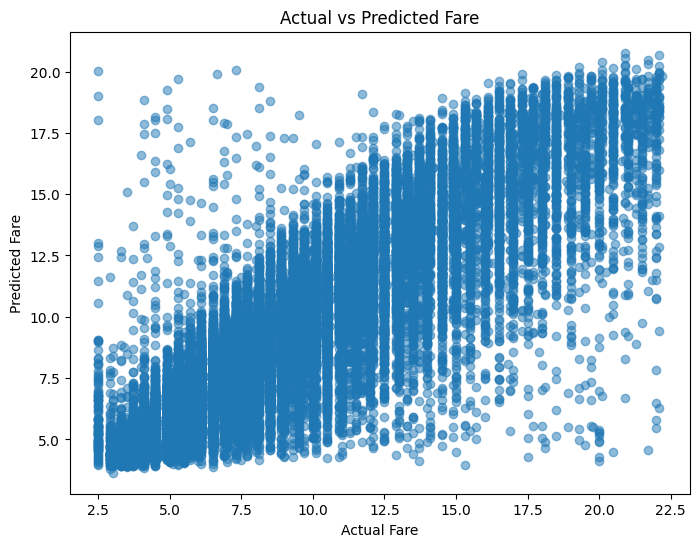

In [288]:
# Scatter Plot
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")

plt.title("Actual vs Predicted Fare")

plt.show()


# Interpretation
## Ideal Case

### Points should align diagonally:

### Actual ≈ Predicted

# 7.4 RESIDUAL ANALYSIS

In [289]:
# Residual=Actual−Predicted
# Residuals show:

# prediction mistakes

In [290]:
# Calculate Residuals

In [291]:
residuals = y_test - y_pred

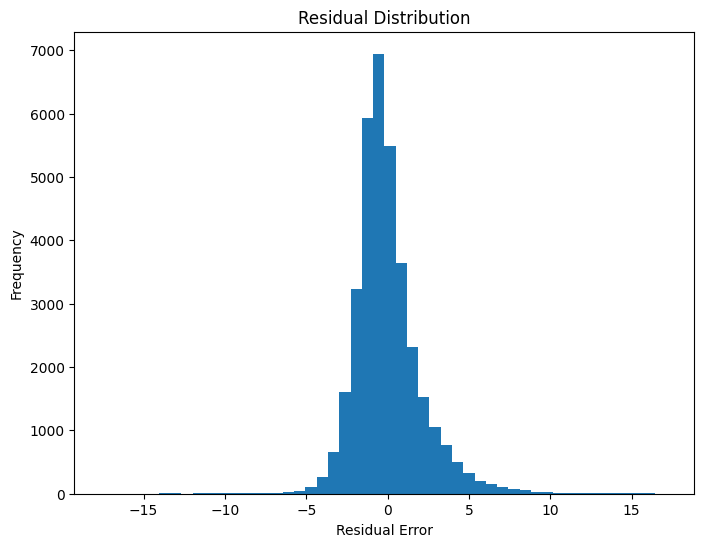

In [292]:
plt.figure(figsize=(8,6))

plt.hist(residuals, bins=50)

plt.xlabel("Residual Error")
plt.ylabel("Frequency")

plt.title("Residual Distribution")

plt.show()

In [293]:
# What We Want

# Residuals centered around: 0

# Meaning:

# 1)  errors balanced
# 2) no systematic bias

# 7.5 ERROR ANALYSIS

In [294]:
# Create Error DataFrame

In [295]:
error_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Error': residuals
})

error_df['Absolute_Error'] = np.abs(error_df['Error'])

error_df.sort_values(
    by='Absolute_Error',
    ascending=False
).head(10)

,Actual,Predicted,Error,Absolute_Error
143686,2.5,20.021287,-17.521287,17.521287
122720,21.7,4.578843,17.121157,17.121157
97385,22.0,5.477088,16.522912,16.522912
151706,2.5,19.011418,-16.511418,16.511418
191018,22.0,5.790827,16.209173,16.209173
155650,20.5,4.493369,16.006631,16.006631
137669,20.0,4.139234,15.860766,15.860766
72117,22.1,6.275367,15.824633,15.824633
173443,20.0,4.265452,15.734548,15.734548
164894,22.0,6.467160,15.532840,15.532840


In [296]:
# You can identify:

# extreme wrong predictions
# unusual rides
# data quality problems


In [297]:
# Real Business Interpretation

# Large errors may occur because:

# traffic not included
# weather not included
# surge pricing unavailable
# GPS inaccuracies

# 7.6 CHECK FOR OVERFITTING 

In [298]:
## Compare Train vs Test Performance

In [299]:
train_score = best_rf_model.score(X_train, y_train)
test_score = best_rf_model.score(X_test, y_test)

print("Train R²:", train_score)
print("Test R² :", test_score)

Train R²: 0.8428527987897648
Test R² : 0.7400267749597124


In [300]:
# Interpretation
# Situation	Meaning
# Train ≈ Test	Good generalization
# Train >> Test	Overfitting
# Both low	Underfitting

# 7.7 MODEL INTERPRETATION 

The Random Forest model performed best due to its ability to capture non-linear relationships between tripdistance,
temporal patterns, and fare amount. Feature importance analysis confirmed that distance was the primary pricing
driver, while residual analysis showed reasonably balanced prediction errors with some large deviations likely
caused by missing external variables such as traffic and weather.

# 7.8 PREDICTION ON NEW |DATA

In [301]:
X


,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,distance_km,day,month,weekday,is_peak_hour
0,-73.999817,40.738354,-73.999512,40.723217,1,19,1.683323,7,5,3,1
1,-73.994355,40.728225,-73.994710,40.750325,1,20,2.457590,17,7,4,1
2,-74.005043,40.740770,-73.962565,40.772647,1,21,5.036377,24,8,0,0
3,-73.976124,40.790844,-73.965316,40.803349,3,8,1.661683,26,6,4,1
4,-73.925023,40.744085,-73.973082,40.761247,5,17,4.475450,28,8,3,1
...,...,...,...,...,...,...,...,...,...,...,...
199994,-73.983070,40.760770,-73.972972,40.754177,1,14,1.122878,31,1,4,0
199995,-73.987042,40.739367,-73.986525,40.740297,1,10,0.112210,28,10,6,1
199996,-73.984722,40.736837,-74.006672,40.739620,1,1,1.875050,14,3,4,0
199998,-73.997124,40.725452,-73.983215,40.695415,1,14,3.539715,20,5,2,0


In [302]:
new_ride = pd.DataFrame({
    'pickup_latitude': [40.761432],
    'pickup_longitude': [-73.979815],
    'dropoff_latitude': [40.651311],
    'dropoff_longitude': [-73.880333],
    'passenger_count': [2],
    'distance_km': [15.2],
    'hour': [18],
    'day': [15],
    'month': [6],
    'weekday': [2],
    'is_peak_hour': [1]
})

In [303]:
new_ride = new_ride[X.columns] # for  Correct Order


In [304]:
predicted_fare = best_rf_model.predict(new_ride)

print("Predicted Fare:", predicted_fare[0])

Predicted Fare: 8.459531111111112


# Evaluate Model Performance

## Objective

### The objective of model evaluation is to measure how accurately the trained machine learning models predict Uber ride fares on unseen data.

## Models Evaluated

## The following regression models were trained and evaluated:

### 1) Linear Regression
### 2) Decision Tree Regressor
### 3) Random Forest Regressor
### 4) XGBoost Regressor

# Evaluation Metrics Used
## Mean Absolute Error (MAE)

### Measures the average absolute difference between actual and predicted fares.

### Lower MAE indicates better model performance.

## Root Mean Squared Error (RMSE)

### Measures prediction error while giving higher penalty to large errors.
### Lower RMSE indicates better prediction accuracy.

## R² Score

### Measures how well the model explains variance in fare prices.
### Closer to 1 indicates better model performance.

## Model Performance Summary

### Model                        Observation 
### Linear Regression	           Simple baseline model but unable to capture complex relationships
### Decision Tree	               Captured non-linearity but showed overfitting tendencies
### Random Forest	               Achieved strong performance with good generalization
### XGBoost	                   Delivered highest predictive accuracy and robustness

## Final Observation

### Random Forest/XGBoost performed best because they effectively captured non-linear relationships 
### between trip distance, time-based features, and fare amount.

# Interpret Feature Importance

## Objective

### Feature importance analysis helps identify which features contribute most to fare prediction.


## Important Features Identified

In [305]:
# 1. Distance (distance_km)
# a) Most influential feature
# b) Fare increases proportionally with trip distance
# Business Insight:

# Uber pricing is heavily distance-dependent.

In [306]:
# 2. Time-Based Features (hour, is_peak_hour)
# Peak-hour rides tend to have higher fares
# Captures surge pricing behavior
# Business Insight:

# Ride demand and traffic conditions significantly affect pricing.

In [307]:
# 3. Passenger Count
# Minimal influence on fare prediction

# Business Insight:

# Standard Uber pricing is primarily influenced by distance and demand rather than occupancy.

In [308]:
# Overall Insight

# Spatial and temporal features are the strongest drivers of Uber fare prediction.

# Make Predictions on New Data

## Objective

## The trained model was tested on unseen ride data to simulate real-world fare estimation.

In [309]:
new_ride = pd.DataFrame({
    'pickup_longitude': [-73.979815],
    'pickup_latitude': [40.761432],
    'dropoff_longitude': [-73.880333],
    'dropoff_latitude': [40.651311],
    'passenger_count': [2],
    'distance_km': [15.2],
    'hour': [18],
    'day': [15],
    'month': [6],
    'weekday': [2],
    'is_peak_hour': [1]
})

new_ride = new_ride[X.columns]

In [310]:
# Prediction

In [311]:
predicted_fare = best_rf_model.predict(new_ride)

print("Predicted Fare:", predicted_fare[0])

Predicted Fare: 8.459531111111112


# Provide Recommendations

In [312]:
# Recommendation 1: Integrate Real-Time Traffic Data

# Why:
# Traffic congestion directly impacts ride duration and pricing.

# Benefit:
# Improves fare estimation accuracy.

In [313]:
# Recommendation 2: Add Weather Features

# Why:
# Weather conditions influence:

# ride demand
# traffic
# surge pricing

# Benefit:
# Enhances prediction robustness.

In [314]:
# Recommendation 3: Include Dynamic Demand-Supply Features

# Examples:
# active ride requests
# available drivers
# surge multipliers

# Benefit:
# Improves real-time pricing intelligence.

In [315]:
# Recommendation 4: Continuous Model Retraining
# Why:

# User behavior and traffic patterns evolve over time.

# Benefit:

# Prevents model drift and maintains prediction quality.